# Choosing the right classification model

in this notebook, we will decide which model is the best for our situation.
we will make 2 copies of the dataset,for two diffrent strategies (SMOTE, class_weight=balanced).
use stratifiedKfold as Cross-Validation. 
test on 5 diffrent models for two startegies (4*2), 2 Pipelines for each strategy contains the same 5 models:

- LogisticRegression
- LinearSVM
- XGBoost
- RandomForest


In [1]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# crossvalidation related libraries
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, average_precision_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
# model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

In [6]:
df = pd.read_csv("../data/preprocessed/creditcard_Processed.csv")

# Dataset splitting

my vision is testing 5 models with 2 data strategies, and evaluating the chosen model with non trained dataset.
So in this section i will split the processed dataset into train and test with 80/20 ratio whil preserving the class imbalance

In [7]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,      # preserves class proportions
    random_state=42
)

print("Original:")
print(y.value_counts(normalize=True) * 100)

print("\nTrain:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest:")
print(y_test.value_counts(normalize=True) * 100)

Original:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

Train:
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Test:
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [12]:
def make_smote_pipe(model):
    return Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])


def make_weight_model(name):
    if name == "LogReg":
        return LogisticRegression( class_weight="balanced")

    if name == "LinearSVM":
        return LinearSVC(class_weight="balanced")

    if name == "RandomForest":
        return RandomForestClassifier(class_weight="balanced")

    if name == "XGBoost":
        scale = y.value_counts()[0] / y.value_counts()[1]
        return XGBClassifier(
            eval_metric="logloss",
            scale_pos_weight=scale
        )


base_models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "LinearSVM": LinearSVC(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss")
}


weight_models = {
    name: make_weight_model(name)
    for name in base_models.keys()
}

smote_models = {
    name: make_smote_pipe(model)
    for name, model in base_models.items()
}

In [13]:
def evaluate(pipe, X, y, model_name="model"):
    print(f"\nStarting: {model_name}")

    metrics = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_val)

        rep = classification_report(y_val, preds, output_dict=True)

        metrics.append({
            "precision": rep["1"]["precision"],
            "recall": rep["1"]["recall"],
            "f1": rep["1"]["f1-score"]
        })

    # convert list → mean dict
    return {
        "precision": np.mean([m["precision"] for m in metrics]),
        "recall": np.mean([m["recall"] for m in metrics]),
        "f1": np.mean([m["f1"] for m in metrics]),
    }


In [14]:
smote_results = {}

for name, pipe in smote_models.items():
    smote_results[name] = evaluate(pipe, X_train, y_train)


Starting: model

Starting: model

Starting: model

Starting: model


In [15]:
weight_results = {}

for name, model in weight_models.items():
    pipe = Pipeline([
        ("model", model)
    ])

    weight_results[name] = evaluate(pipe, X_train, y_train)


Starting: model

Starting: model

Starting: model

Starting: model


In [16]:
table = []

for model in smote_results.keys():
    row = {
        "Model": model,

        "SMOTE_precision": smote_results[model]["precision"],
        "SMOTE_recall": smote_results[model]["recall"],
        "SMOTE_f1": smote_results[model]["f1"],

        "NO_SMOTE_precision": weight_results[model]["precision"],
        "NO_SMOTE_recall": weight_results[model]["recall"],
        "NO_SMOTE_f1": weight_results[model]["f1"],
    }

    table.append(row)

df_results = pd.DataFrame(table)
df_results

,Model,SMOTE_precision,SMOTE_recall,SMOTE_f1,NO_SMOTE_precision,NO_SMOTE_recall,NO_SMOTE_f1
0,LogReg,0.052067,0.899439,0.098406,0.055356,0.899404,0.104251
1,LinearSVM,0.064281,0.891474,0.119788,0.069544,0.891474,0.128902
2,RandomForest,0.878864,0.798982,0.836368,0.940010,0.738175,0.826082
3,XGBoost,0.763217,0.812140,0.785504,0.905911,0.798947,0.848524


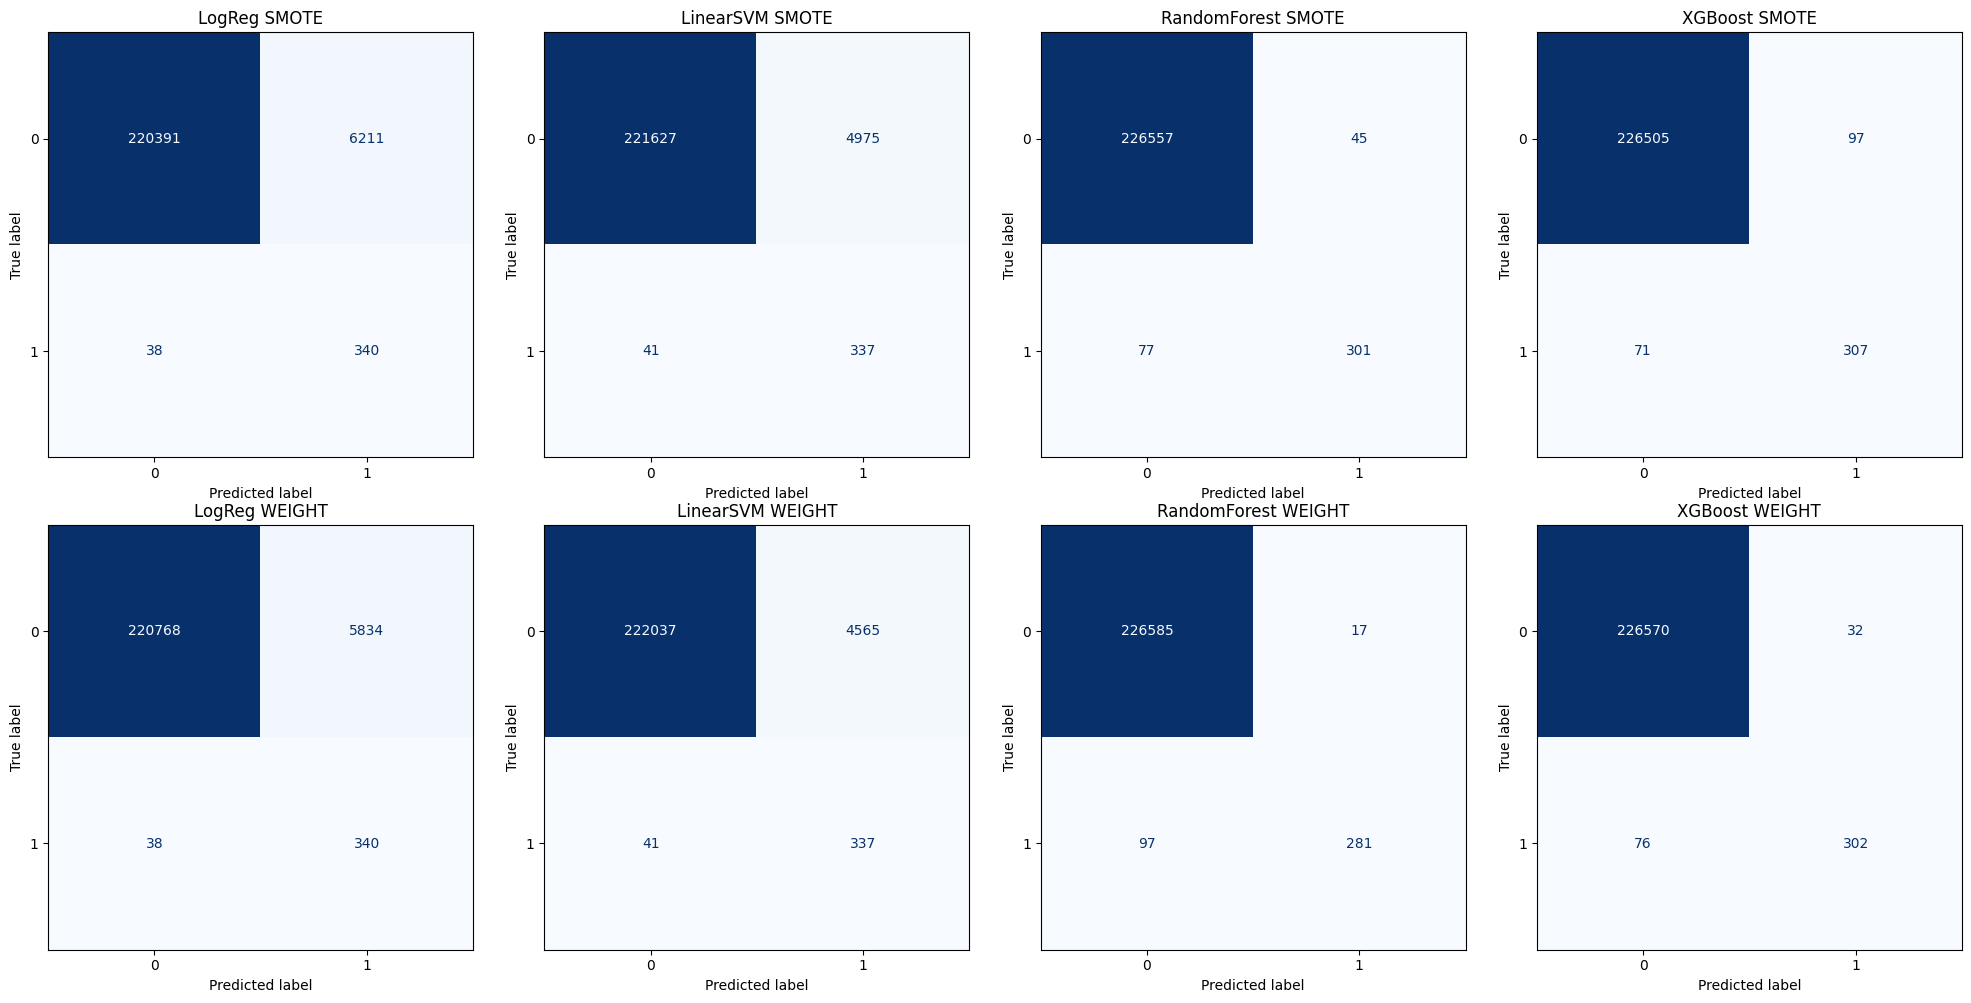

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

all_models = []

# SMOTE
for name, pipe in smote_models.items():
    preds = cross_val_predict(pipe, X_train, y_train, cv=cv)
    cm = confusion_matrix(y_train, preds)
    all_models.append((f"{name} SMOTE", cm))

# WEIGHT
for name, model in weight_models.items():
    pipe = Pipeline([("model", model)])
    preds = cross_val_predict(pipe, X_train, y_train, cv=cv)
    cm = confusion_matrix(y_train, preds)
    all_models.append((f"{name} WEIGHT", cm))

# Plot
for ax, (title, cm) in zip(axes, all_models):
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax, values_format="d", colorbar=False, cmap="Blues")
    ax.set_title(title)

plt.tight_layout()
plt.show()

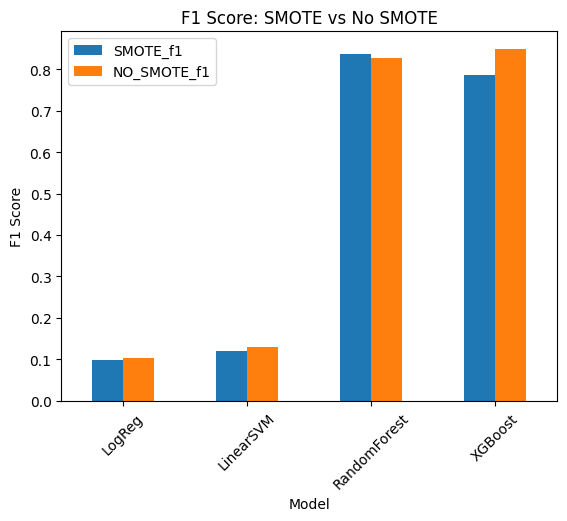

In [18]:
df_plot = df_results.set_index("Model")

df_plot[[
    "SMOTE_f1",
    "NO_SMOTE_f1"
]].plot(kind="bar")

plt.title("F1 Score: SMOTE vs No SMOTE")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.show()

# Conclusion

XGBoost + weight balancing 